<a href="https://colab.research.google.com/github/quinterogilalejandro-wq/Semana-9-/blob/main/Implementaci%C3%B3n_de_Data_Augmentation_y_Transfer_Learning_en_Im%C3%A1genes_en_Google_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

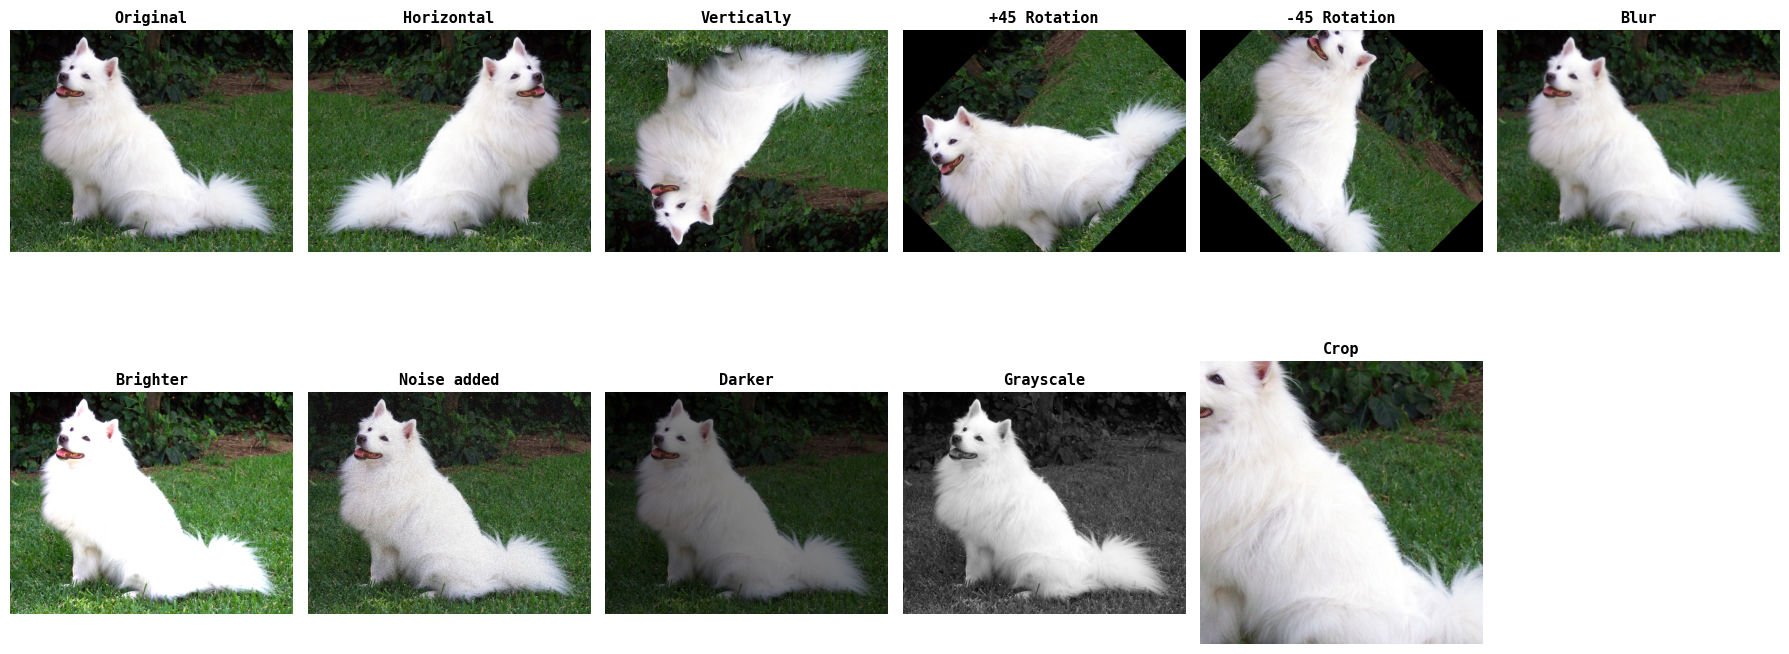

In [26]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║                                                                  ║
# ║    DATA AUGMENTATION                                             ║
# ║                                                                  ║
# ╚══════════════════════════════════════════════════════════════════╝

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T
import albumentations as A
import imgaug.augmenters as iaa
from PIL import Image
import urllib.request
import os

# 1. OBTENCIÓN AUTOMÁTICA DE IMAGEN
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/can.jpg"
path = "image_d7a6dc.jpg"

if not os.path.exists(path):
    print("Descargando imagen de muestra...")
    urllib.request.urlretrieve(url, path)

# 2. CARGA DE DATOS
image_cv2 = cv2.imread(path)
image_cv2 = cv2.cvtColor(image_cv2, cv2.COLOR_BGR2RGB)
image_pil = Image.open(path)

# 3. DEFINICIÓN DE TRANSFORMACIONES UNIFICADAS

# Albumentations
aug_gray = A.ToGray(p=1)

# Imgaug
noise_seq = iaa.AdditiveGaussianNoise(scale=0.15*255)
bright_seq = iaa.Multiply(1.5)
dark_seq = iaa.Multiply(0.5)

# 4. GENERACIÓN DE RESULTADOS (Replicando la estructura de la imagen de referencia)
results = {
    "Original": image_cv2,
    "Horizontal": cv2.flip(image_cv2, 1),
    "Vertically": cv2.flip(image_cv2, 0),
    "+45 Rotation": np.array(T.functional.rotate(image_pil, 45)),
    "-45 Rotation": np.array(T.functional.rotate(image_pil, -45)),
    "Blur": cv2.GaussianBlur(image_cv2, (15, 15), 0),
    "Brighter": bright_seq.augment_image(image_cv2),
    "Noise added": noise_seq.augment_image(image_cv2),
    "Darker": dark_seq.augment_image(image_cv2),
    "Grayscale": aug_gray(image=image_cv2)["image"],
    "Crop": np.array(T.CenterCrop(min(image_pil.size)//1.5)(image_pil))
}

# 5. VISUALIZACIÓN FINAL
titles = list(results.keys())
images = list(results.values())

plt.figure(figsize=(18, 8))
for i in range(len(images)):
    plt.subplot(2, 6, i+1)
    plt.imshow(images[i])
    plt.title(titles[i], fontsize=11, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [23]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║                                                                  ║
# ║    TRANSFER LEARNING                                             ║
# ║                                                                  ║
# ╚══════════════════════════════════════════════════════════════════╝

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. CARGA DEL MODELO BASE (PREENTRENADO)
# Usamos pesos de ImageNet y excluimos la capa superior (Top) para añadir la nuestra
base_model = MobileNetV2(input_shape=(160, 160, 3),
                         include_top=False,
                         weights='imagenet')

# CONGELAR EL MODELO BASE
# Evitamos que los pesos ya aprendidos se modifiquen durante el entrenamiento inicial
base_model.trainable = False

# 2. CONSTRUCCIÓN DEL MODELO PERSONALIZADO
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Convierte el mapa de características en un vector
    layers.Dropout(0.2),             # Regularización para evitar sobreajuste
    layers.Dense(1, activation='sigmoid') # Capa de salida (ejemplo: clasificación binaria)
])

# 3. COMPILACIÓN
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Resumen de la arquitectura
model.summary()

# 4. EXPLICACIÓN DE LA EFICIENCIA
print("\n[JUSTIFICACIÓN TÉCNICA]")
print("1. Reutilización de Características: El modelo base ya sabe detectar bordes, texturas y formas.")
print("2. Ahorro de Tiempo: Solo entrenamos los 'pesos' de las capas finales.")
print("3. Menos Datos: Funciona bien incluso con conjuntos de datos pequeños.")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


[JUSTIFICACIÓN TÉCNICA]
1. Reutilización de Características: El modelo base ya sabe detectar bordes, texturas y formas.
2. Ahorro de Tiempo: Solo entrenamos los 'pesos' de las capas finales.
3. Menos Datos: Funciona bien incluso con conjuntos de datos pequeños.
